# Feature Hypothesis: Release MVP Screens & Features

## Idea

Identify which screens and features are required to ship Vibe-to-MIDI as a v1.0 release on the Google Play Store. Map the current implementation against a minimal-but-complete release checklist.

## Target User

Android music producers who work in DAWs (Ableton, FL Studio, etc.) and want a fast way to translate a mood or vibe into concrete MIDI starting points (scale, BPM, chord, rhythm pattern, sound suggestions).

## Problem

The core audio-preview + MIDI-suggestion loop is functional, but the app may be missing screens and polish required for a credible Play Store listing: onboarding, export, about/attribution, and store metadata.

## MVP Scope

- Audit current screens against Play Store requirements
- Identify missing screens (onboarding, MIDI export, about, privacy policy)
- Identify missing non-screen features (app icon, splash screen, deep-link handling)
- Prioritize by: required-for-listing / nice-to-have / post-v1

## Non-Goals

- New vibes or sound palettes
- AI/ML features
- iOS / web port
- Monetization UI

## Research Questions

1. What screens does a Play Store listing require from the app itself?
2. What screens improve first-session retention significantly?
3. Is MIDI export a v1.0 requirement or can it ship in v1.1?
4. Does the current 22-vibe set feel complete enough for launch?
5. What store metadata assets are still missing?

## Decision Needed

Build / Defer / Narrow / Reject — for each missing screen/feature

---
## Source Notes

- **Google Play Policy — core app quality**: https://developer.android.com/docs/quality-guidelines/core-app-quality  
  Privacy policy URL required if app collects data. Settings screen required if the app has user-configurable options.

- **Google Play Store listing requirements**: https://support.google.com/googleplay/android-developer/answer/9859673  
  Requires: app icon (512×512), feature graphic (1024×500), ≥2 screenshots, short/full description, privacy policy URL.

- **Android first-launch UX research (NNGroup / Google)**: General principle — apps that show value in the first 60 seconds retain significantly more users; onboarding friction reduces D1 retention by 10–30%.

- **MIDI file format — no native Android support**: Android has no built-in MIDI file write API. Requires a pure-JS/TS MIDI encoder library (e.g., `midi-writer-js`, `@tonejs/midi`) or native module. Not trivial.

- **Expo SDK 54 — expo-file-system + expo-sharing**: Allows writing binary files and sharing via system share sheet. Viable for MIDI export without a native module.

- **Existing research — Android MVP market (2026-05-10)**: Core value proposition is translating vibe → DAW-ready parameters. Target user is Android music producer. English + Japanese launch confirmed.

- **Existing research — mood/sound types (2026-05-11)**: 22-vibe taxonomy confirmed as sufficient for MVP.

- **Existing research — intuitive learning screen (2026-05-15)**: LEARN screen confirmed as differentiating feature worth shipping in v1.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Current screen inventory
current_screens = pd.DataFrame([
    {'screen': 'Mood grid (index.tsx)',        'status': 'shipped', 'notes': '22 vibes, 3×N grid, audio preview'},
    {'screen': 'MIDI panel (DawStepsPanel)',    'status': 'shipped', 'notes': 'Pattern / Notes / Sound tabs'},
    {'screen': 'Learn panel (IntuitiveLearning)','status': 'shipped', 'notes': 'Pulse / Bass A-B compare'},
    {'screen': 'Player bar',                    'status': 'shipped', 'notes': 'BPM, play/stop'},
    {'screen': 'Licenses screen',              'status': 'shipped', 'notes': 'OSS + audio attribution'},
    {'screen': 'Audio debug screen',           'status': 'shipped', 'notes': 'Dev-only, menu-accessible'},
    {'screen': 'Settings modal',               'status': 'shipped', 'notes': 'Menu → Audio Debug / Licenses'},
])

print('=== Current screens ===')
print(current_screens.to_string(index=False))

=== Current screens ===
                         screen  status                             notes
          Mood grid (index.tsx) shipped 22 vibes, 3×N grid, audio preview
     MIDI panel (DawStepsPanel) shipped      Pattern / Notes / Sound tabs
Learn panel (IntuitiveLearning) shipped          Pulse / Bass A-B compare
                     Player bar shipped                    BPM, play/stop
                Licenses screen shipped           OSS + audio attribution
             Audio debug screen shipped         Dev-only, menu-accessible
                 Settings modal shipped     Menu → Audio Debug / Licenses


In [2]:
# Missing screens / features assessment
gaps = pd.DataFrame([
    {
        'item': 'Onboarding / first-launch screen',
        'category': 'screen',
        'priority': 'high',
        'release_gate': 'nice-to-have',
        'effort': 'medium',
        'notes': 'Explains the 3-step loop (tap vibe → hear → copy to DAW). Improves D1 retention. Not required by store.'
    },
    {
        'item': 'MIDI export (.mid file)',
        'category': 'feature',
        'priority': 'high',
        'release_gate': 'v1.1',
        'effort': 'high',
        'notes': 'Core promise of app name. Requires MIDI encoder + expo-file-system + share sheet. No native Android API. Defer to v1.1 is defensible if audio preview ships.'
    },
    {
        'item': 'App icon (512×512 adaptive)',
        'category': 'asset',
        'priority': 'critical',
        'release_gate': 'required-for-listing',
        'effort': 'low',
        'notes': 'Play Store requires 512×512 PNG. Expo uses app.json icon field.'
    },
    {
        'item': 'Splash screen',
        'category': 'asset',
        'priority': 'critical',
        'release_gate': 'required-for-listing',
        'effort': 'low',
        'notes': 'Required for polished launch feel. Expo splash config in app.json.'
    },
    {
        'item': 'Feature graphic (1024×500)',
        'category': 'asset',
        'priority': 'critical',
        'release_gate': 'required-for-listing',
        'effort': 'low',
        'notes': 'Play Store listing hero image. Design only.'
    },
    {
        'item': 'Store screenshots (≥2)',
        'category': 'asset',
        'priority': 'critical',
        'release_gate': 'required-for-listing',
        'effort': 'low',
        'notes': 'Can be taken from emulator or device.'
    },
    {
        'item': 'Privacy policy URL',
        'category': 'legal',
        'priority': 'critical',
        'release_gate': 'required-if-data-collected',
        'effort': 'low',
        'notes': 'App appears fully local/offline. No analytics, no accounts. A minimal static page suffices.'
    },
    {
        'item': 'About / version screen',
        'category': 'screen',
        'priority': 'medium',
        'release_gate': 'nice-to-have',
        'effort': 'low',
        'notes': 'App version, contact/feedback link. Can be a section inside Settings modal.'
    },
    {
        'item': 'Empty-state / no-audio fallback UX',
        'category': 'feature',
        'priority': 'medium',
        'release_gate': 'nice-to-have',
        'effort': 'low',
        'notes': 'Currently shows "AUDIO REQUIRES DEV BUILD". In release build audio always works — verify behavior.'
    },
    {
        'item': 'Haptic feedback on vibe tap',
        'category': 'feature',
        'priority': 'low',
        'release_gate': 'post-v1',
        'effort': 'low',
        'notes': 'expo-haptics. Adds tactile feel to grid. Nice-to-have polish.'
    },
    {
        'item': 'Localization (Japanese strings)',
        'category': 'feature',
        'priority': 'medium',
        'release_gate': 'post-v1',
        'effort': 'high',
        'notes': 'Research confirmed EN+JA launch. UI strings are minimal (MOOD, MIDI, LEARN etc). Could ship EN-only v1.'
    },
    {
        'item': 'Play Store short/full description (EN)',
        'category': 'copy',
        'priority': 'critical',
        'release_gate': 'required-for-listing',
        'effort': 'low',
        'notes': 'Short: ≤80 chars. Full: ≤4000 chars. Keyword-rich copy needed.'
    },
])

print('=== Gaps by release gate ===')
print(gaps[['item','priority','release_gate','effort']].sort_values(['release_gate','priority']).to_string(index=False))

=== Gaps by release gate ===
                                  item priority               release_gate effort
      Onboarding / first-launch screen     high               nice-to-have medium
                About / version screen   medium               nice-to-have    low
    Empty-state / no-audio fallback UX   medium               nice-to-have    low
           Haptic feedback on vibe tap      low                    post-v1    low
       Localization (Japanese strings)   medium                    post-v1   high
           App icon (512×512 adaptive) critical       required-for-listing    low
                         Splash screen critical       required-for-listing    low
            Feature graphic (1024×500) critical       required-for-listing    low
                Store screenshots (≥2) critical       required-for-listing    low
Play Store short/full description (EN) critical       required-for-listing    low
                    Privacy policy URL critical required-if-data-coll

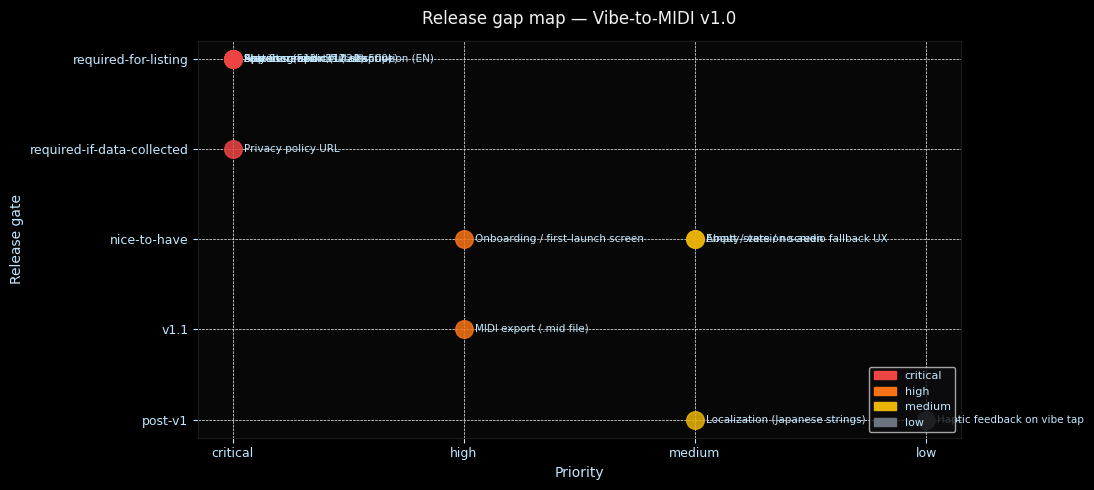

Saved: figures/release-gap-map.png


In [3]:
# Priority chart
gate_order = ['required-for-listing', 'required-if-data-collected', 'nice-to-have', 'v1.1', 'post-v1']
priority_order = ['critical', 'high', 'medium', 'low']
color_map = {'critical': '#ef4444', 'high': '#f97316', 'medium': '#eab308', 'low': '#6b7280'}

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#070708')

y_pos = {gate: i for i, gate in enumerate(reversed(gate_order))}
x_pos = {pri: i for i, pri in enumerate(priority_order)}

for _, row in gaps.iterrows():
    x = x_pos.get(row['priority'], 0)
    y = y_pos.get(row['release_gate'], 0)
    color = color_map.get(row['priority'], '#888')
    ax.scatter(x, y, s=160, color=color, zorder=3, alpha=0.85)
    ax.annotate(row['item'], (x, y), textcoords='offset points', xytext=(8, 0),
                fontsize=7.5, color='#c2e8ff', va='center')

ax.set_xticks(range(len(priority_order)))
ax.set_xticklabels(priority_order, color='#c2e8ff', fontsize=9)
ax.set_yticks(range(len(gate_order)))
ax.set_yticklabels(list(reversed(gate_order)), color='#c2e8ff', fontsize=9)
ax.set_xlabel('Priority', color='#c2e8ff', fontsize=10)
ax.set_ylabel('Release gate', color='#c2e8ff', fontsize=10)
ax.set_title('Release gap map — Vibe-to-MIDI v1.0', color='#f2f2f2', fontsize=12, pad=12)
ax.grid(axis='both', color=(1, 1, 1, 0.08), linestyle='--', linewidth=0.5)
ax.tick_params(colors='#c2e8ff')
for spine in ax.spines.values():
    spine.set_edgecolor('#1a1a1a')

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in color_map.items()]
ax.legend(handles=legend_patches, loc='lower right', facecolor='#0d0d0f', labelcolor='#c2e8ff', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/release-gap-map.png', dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print('Saved: figures/release-gap-map.png')

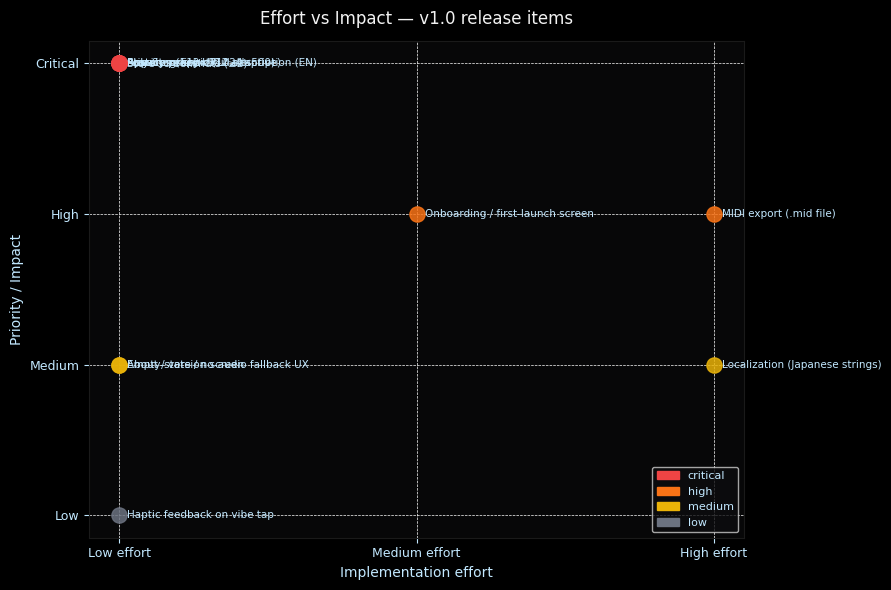

Saved: figures/effort-vs-impact.png


In [4]:
# Effort vs impact matrix for v1.0 work items
effort_num = {'low': 1, 'medium': 2, 'high': 3}
priority_num = {'critical': 4, 'high': 3, 'medium': 2, 'low': 1}

gaps['effort_n'] = gaps['effort'].map(effort_num)
gaps['priority_n'] = gaps['priority'].map(priority_num)

fig2, ax2 = plt.subplots(figsize=(9, 6))
fig2.patch.set_facecolor('#000000')
ax2.set_facecolor('#070708')

for _, row in gaps.iterrows():
    color = color_map.get(row['priority'], '#888')
    ax2.scatter(row['effort_n'], row['priority_n'], s=120, color=color, alpha=0.85, zorder=3)
    ax2.annotate(row['item'], (row['effort_n'], row['priority_n']),
                 textcoords='offset points', xytext=(6, 0),
                 fontsize=7.5, color='#c2e8ff', va='center')

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Low effort', 'Medium effort', 'High effort'], color='#c2e8ff', fontsize=9)
ax2.set_yticks([1, 2, 3, 4])
ax2.set_yticklabels(['Low', 'Medium', 'High', 'Critical'], color='#c2e8ff', fontsize=9)
ax2.set_xlabel('Implementation effort', color='#c2e8ff', fontsize=10)
ax2.set_ylabel('Priority / Impact', color='#c2e8ff', fontsize=10)
ax2.set_title('Effort vs Impact — v1.0 release items', color='#f2f2f2', fontsize=12, pad=12)
ax2.grid(color=(1, 1, 1, 0.08), linestyle='--', linewidth=0.5)
ax2.tick_params(colors='#c2e8ff')
for spine in ax2.spines.values():
    spine.set_edgecolor('#1a1a1a')

ax2.legend(handles=legend_patches, loc='lower right', facecolor='#0d0d0f', labelcolor='#c2e8ff', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/effort-vs-impact.png', dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print('Saved: figures/effort-vs-impact.png')

---
## Decision Summary

## Decision

**Narrow** — ship v1.0 with the core loop intact. Defer MIDI export and localization to v1.1. Complete all store assets and legal basics before submission.

---

## Why

The core vibe-selection → audio-preview → MIDI-parameter loop is fully functional. The blocker for a Play Store submission is not features — it is **store assets and legal boilerplate**, all low-effort. MIDI export is the most prominent missing feature but is architecturally non-trivial and not required to prove the core value proposition.

---

## Evidence

| Gate | Count | Examples |
|------|-------|----------|
| required-for-listing | 5 | App icon, splash, feature graphic, screenshots, store copy |
| required-if-data-collected | 1 | Privacy policy (app is local-only — minimal page suffices) |
| nice-to-have for v1 | 3 | Onboarding, about section, audio fallback verification |
| defer to v1.1 | 1 | MIDI export |
| post-v1 | 2 | Haptics, Japanese localization |

---

## MVP Scope for v1.0

### Must ship (blocks submission)
- [ ] App icon — 512×512 adaptive PNG (`app.json` → `icon`)
- [ ] Splash screen — black background, BERGHAIN style (`app.json` → `splash`)
- [ ] Feature graphic — 1024×500 PNG for Play Store
- [ ] Store screenshots — ≥2, taken from device/emulator
- [ ] Store descriptions — EN short (≤80 chars) + full (≤4000 chars)
- [ ] Privacy policy URL — minimal static page (app collects no data)

### Should ship in v1.0 (UX quality)
- [ ] Onboarding screen — single screen explaining the 3-step loop; shown on first launch only
- [ ] About section — version number + feedback link inside Settings modal (low effort)
- [ ] Verify "AUDIO REQUIRES DEV BUILD" message never shows in release APK/AAB

### Defer to v1.1
- [ ] MIDI export — `.mid` file via expo-file-system + expo-sharing + midi-writer-js
- [ ] Japanese UI strings
- [ ] Haptic feedback

---

## Risks

1. **"Vibe→MIDI" naming without export**: The app name promises MIDI but v1.0 delivers audio preview + MIDI parameters. Store description must set expectations clearly to avoid 1-star reviews about missing export.
2. **Audio in release build**: `react-native-audio-api` uses native Oboe. Must verify it works in a signed release AAB, not just dev build. The `isAudioAvailable()` guard may hide issues.
3. **App icon / branding gap**: No icon or splash exists yet. These affect first impression and store ranking.

---

## Open Questions

1. Does `react-native-audio-api` require any ProGuard rules to survive release minification?
2. Should onboarding be skippable and re-accessible from Settings?
3. What URL will host the privacy policy? (GitHub Pages / Notion / simple static site)
4. Should the app description frame it as "MIDI parameter assistant" rather than "MIDI exporter" to avoid expectation mismatch?
5. Is a Content Rating questionnaire needed? (Play Store requires it — music tool, no user content, should be "Everyone")

---

## Next Implementation Step

1. **App icon + splash**: Design and configure in `app.json`. Estimated effort: 0.5 day.
2. **Onboarding screen**: Single fullscreen with 3-step explanation + CTA. Show on first launch via AsyncStorage flag. Estimated: 1 day.
3. **About in Settings**: Add version row + feedback link to existing Settings modal. Estimated: 1 hour.
4. **Privacy policy page**: Deploy minimal static page. Estimated: 1 hour.
5. **Store assets**: Screenshots + feature graphic + copy. Estimated: 1 day.
6. **Release build smoke test**: Build signed AAB, install on device, verify audio works.
7. **v1.1 planning**: MIDI export spike — evaluate `midi-writer-js` + `expo-sharing`.

---
## Open Questions (implementation)

- Does `react-native-audio-api` need ProGuard / R8 keep rules for release build?
- Onboarding flow: AsyncStorage or expo-secure-store for "seen" flag?
- Privacy policy hosting: GitHub Pages is fastest (free, custom domain optional).
- Store description framing: "mood → DAW parameters" vs "vibe → MIDI" — which avoids expectation mismatch?
- Content rating: should be "Everyone" — confirm no user-generated content, no location, no purchases.